## New section# Week 3 - Task 1
## Neural Network for Image Classification

### MNIST Handwritten Digit Classification using CNN

This project builds a Convolutional Neural Network (CNN)
using TensorFlow/Keras to classify handwritten digits from 0 to 9.

Dataset: MNIST Handwritten Digits Dataset
Framework: TensorFlow / Keras

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [3]:
print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print("Image size:", X_train[0].shape)

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Image size: (28, 28)


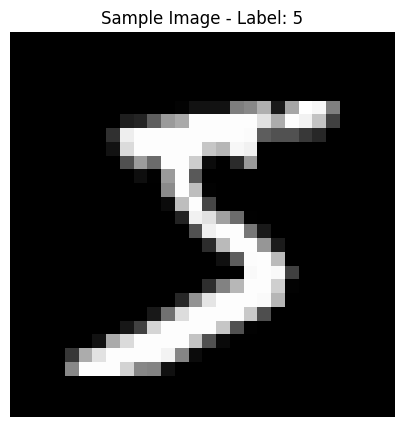

In [4]:
plt.figure(figsize=(5, 5))

plt.imshow(X_train[0], cmap="gray")
plt.title(f"Sample Image - Label: {y_train[0]}")
plt.axis("off")

plt.show()

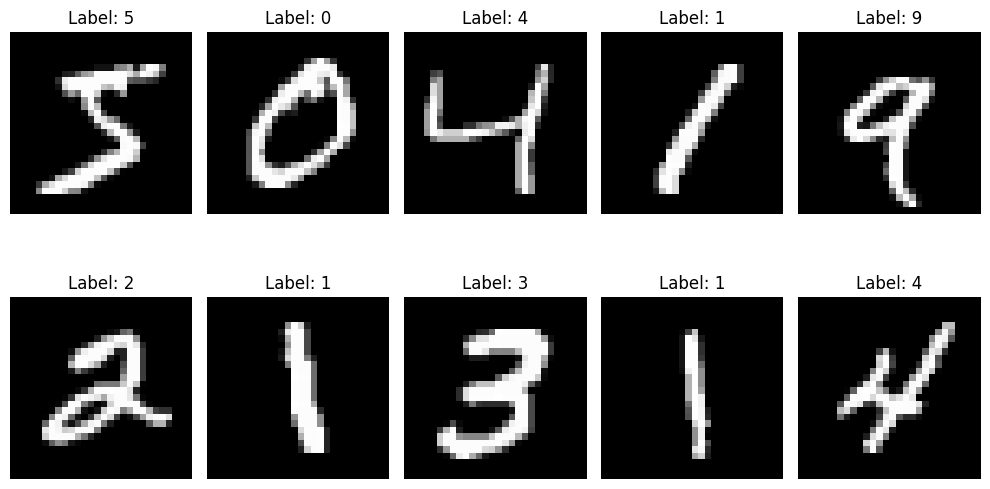

In [5]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Normalize pixel values from 0-255 to 0-1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension for CNN

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [7]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9448 - loss: 0.1853 - val_accuracy: 0.9821 - val_loss: 0.0629
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9836 - loss: 0.0517 - val_accuracy: 0.9875 - val_loss: 0.0431
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9889 - loss: 0.0355 - val_accuracy: 0.9875 - val_loss: 0.0432
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9911 - loss: 0.0278 - val_accuracy: 0.9877 - val_loss: 0.0449
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9847 - val_loss: 0.0560
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9952 - loss: 0.0147 - val_accuracy: 0.9866 - val_loss: 0.0463
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9952 - loss: 0.0136 - val_accuracy: 0.9908 - val_loss: 0.0383
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9966 - loss: 0.0100 - val_accuracy: 0.

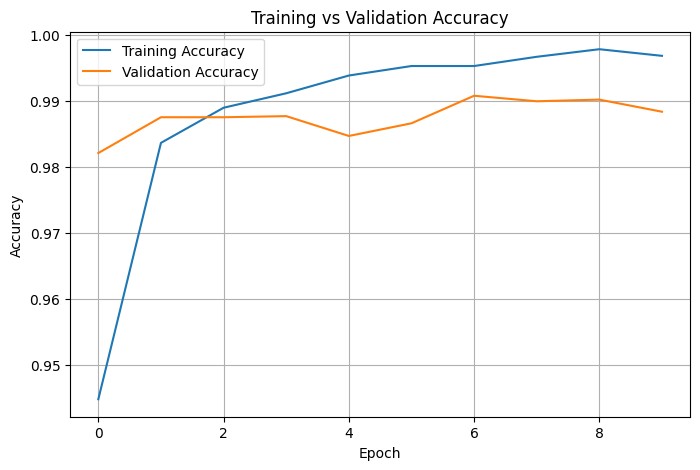

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

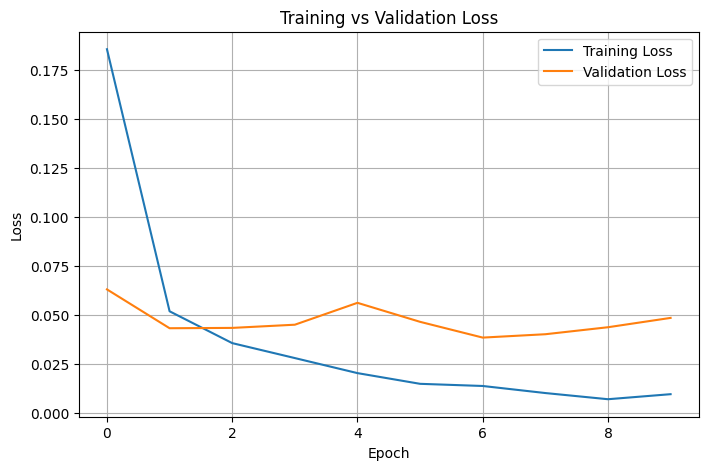

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.04751071333885193
Test Accuracy: 0.987500011920929
Test Accuracy: 98.75%


In [14]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions generated successfully.


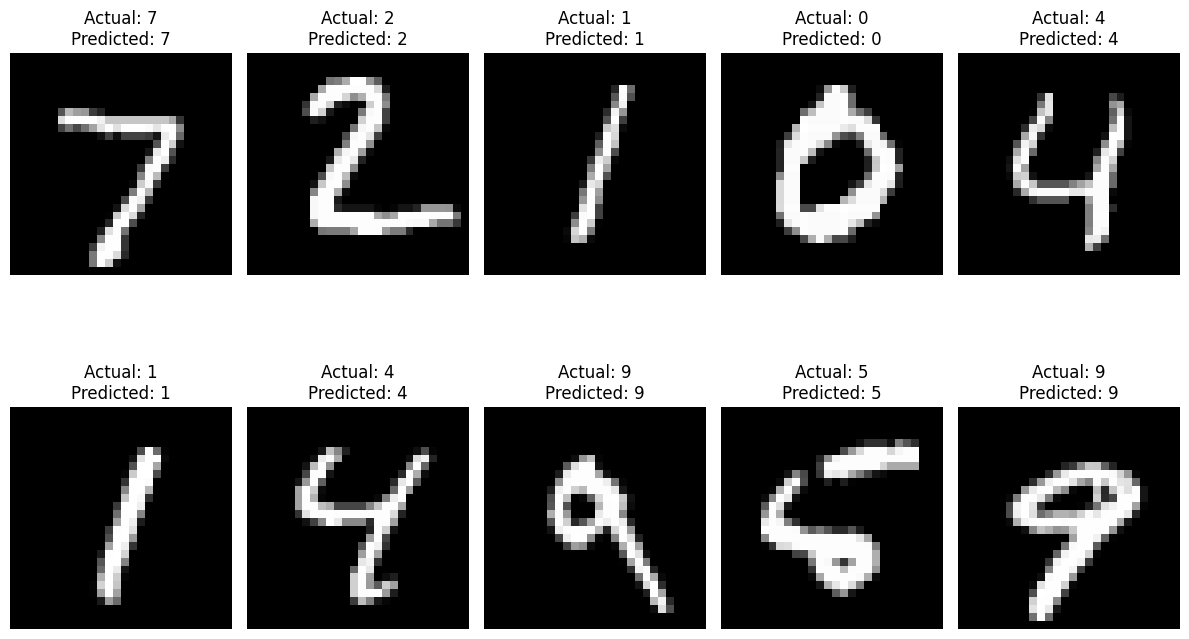

In [15]:
plt.figure(figsize=(12, 8))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
for i in range(10):

    print(
        f"Image {i + 1}: "
        f"Actual = {y_test[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )

Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4
Image 6: Actual = 1, Predicted = 1
Image 7: Actual = 4, Predicted = 4
Image 8: Actual = 9, Predicted = 9
Image 9: Actual = 5, Predicted = 5
Image 10: Actual = 9, Predicted = 9


In [17]:
print("====================================")
print("FINAL MODEL RESULT")
print("====================================")
print(f"Dataset: MNIST")
print(f"Model: Convolutional Neural Network (CNN)")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

FINAL MODEL RESULT
Dataset: MNIST
Model: Convolutional Neural Network (CNN)
Test Accuracy: 98.75%
